# Set up
**Import libraries**

In [1]:
from io import StringIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from knmy import knmy
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    recall_score,
)

**Load and merge datasets**

In [2]:

df = pd.read_csv("../data/bunny.csv", dtype={'Oryctolagus cuniculus': str})
habitat = pd.read_csv("../data/habitats.csv")

# Merge habitats with bunny data with only matching decimalLatitude and decimalLongitude values
df = df.merge(habitat, how="left", on=["decimalLatitude", "decimalLongitude"])

In [3]:
df["eventDate"] = pd.to_datetime(df["eventDate"]).dt.normalize()

start_date = df["eventDate"].min().strftime("%Y%m%d")
end_date   = df["eventDate"].max().strftime("%Y%m%d")

weather_raw = knmy.get_knmi_data(
    type="daily",
    stations=[260],
    start=start_date,
    end=end_date
)

# KNMI data starts with a header after the '#' comments. 
# We skip the comments and treat it as a standard CSV.
# We use skipinitialspace=True to handle the alignment spaces.
weather_df = pd.read_csv(
    StringIO(weather_raw), 
    comment='#', 
    skipinitialspace=True,
    header=None
)

# Mapping based on standard KNMI daily index:
# 0: STN, 1: YYYYMMDD, 11: TG, 18: SQ, 22: RH
weather_df = weather_df.rename(columns={
    0: "STN",
    1: "YYYYMMDD",
    11: "TG",
    18: "SQ",
    22: "RH"
})

# Ensure YYYYMMDD is treated as a string before date conversion
weather_df["YYYYMMDD"] = weather_df["YYYYMMDD"].astype(str)

weather_df["eventDate"] = pd.to_datetime(
    weather_df["YYYYMMDD"], 
    format="%Y%m%d", 
    errors="coerce"
).dt.normalize()

# KNMI values are in 0.1 units (e.g., 115 = 11.5°C)
weather_df["temp_mean"] = pd.to_numeric(weather_df["TG"], errors="coerce") / 10
weather_df["precip_sum"] = pd.to_numeric(weather_df["RH"], errors="coerce") / 10
weather_df["sunshine_duration"] = pd.to_numeric(weather_df["SQ"], errors="coerce") / 10


weather_df = weather_df.dropna(subset=["eventDate"])


df["eventDate"] = df["eventDate"].dt.normalize()
weather_df["eventDate"] = weather_df["eventDate"].dt.normalize()

df = df.merge(
    weather_df[[
        "eventDate",
        "temp_mean",
        "precip_sum",
        "sunshine_duration"
    ]],
    on="eventDate",
    how="left"
)

print("✔ Shape:", df.shape)
print(df.head())

✔ Shape: (12558786, 18)
   decimalLatitude  decimalLongitude  eventDate  total_observations  \
0            50.75              5.65 2010-01-01                 0.0   
1            50.75              5.65 2010-01-02                26.0   
2            50.75              5.65 2010-01-03                 3.0   
3            50.75              5.65 2010-01-04                 0.0   
4            50.75              5.65 2010-01-05                 0.0   

   speciesgroup_observations Oryctolagus cuniculus  agricultural   built  \
0                          0                     0        1.7747  0.0568   
1                          0                     0        1.7747  0.0568   
2                          0                     0        1.7747  0.0568   
3                          0                     0        1.7747  0.0568   
4                          0                     0        1.7747  0.0568   

   coast  forest   other  sand/heather   water  wetland  main_habitat  \
0    0.0  0.0616  0

**Feature enginering**

Because of in the CRISP-DM cycle we went back and forth between data understanding and data preparation and therefore need need the data preparation part feature enigerening before data understanding we are placing it here

In [4]:
df["eventDate"] = pd.to_datetime(df["eventDate"])

df["spotted"] = (
    pd.to_numeric(df["Oryctolagus cuniculus"], errors="coerce")
    .fillna(0)
    .gt(0)
    .astype(int)
)

df = df.sort_values(["decimalLatitude", "decimalLongitude", "eventDate"])

# Create the future spotted flag
df["is_spotted"] = (
    df.groupby(["decimalLatitude", "decimalLongitude"])["spotted"]
      .transform(lambda x: x[::-1].rolling(window=7, min_periods=1).max()[::-1].shift(-1).fillna(0).astype(int))
)

# to find time patterns
df["day_of_year"] = df["eventDate"].dt.dayofyear
df['day_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)

---

# 1. Business Understanding

**Business Objective** 

* The objective of this project is to develop a predictive model for observations of Oryctolagus cuniculus using environmental and temporal factors such as habitat type, seasonality, temperature, precipitation, and geographic location.
The model aims to predict where and when rabbit observations are most likely to occur, helping improve biodiversity monitoring, ecological research, and wildlife management decisions.

**Business Success Criteria**

* The model will be considered successful if it:
    * Achieves at least 75% prediction accuracy on unseen observation data
    * Correctly identifies seasonal and habitat-related patterns in rabbit observations
    * Maintains stable performance across different geographic regions and weather conditions

**Data Mining Goals**

* Develop a classification model that predicts the likelihood of observing Oryctolagus cuniculus using environmental variables such as habitat type, seasonality, temperature, precipitation, and geographic location.

**Data Mining Success Criteria**

* Our model should achieve at least:
75% accuracy in predicting observations of Oryctolagus cuniculus
70% precision when identifying locations and time periods with rabbit observations
75% recall in detecting actual rabbit observation occurrences based on habitat, seasonal, and weather-related variables
The model should also maintain stable predictive performance across different regions and seasons.

---


# 2.1 Data understanding
**Data exploration**

In [5]:
df.head()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Oryctolagus cuniculus,agricultural,built,coast,forest,...,wetland,main_habitat,temp_mean,precip_sum,sunshine_duration,spotted,is_spotted,day_of_year,day_sin,day_cos
12558769,3.5,52.8,2026-01-14,10.0,1011,3,NaN,NaN,NaN,NaN,...,NaN,NaN,6.1,3.6,6.9,1,0,14,0.238673,0.971100
12558767,3.5,52.9,2026-01-12,100.0,1011,unknown,NaN,NaN,NaN,NaN,...,NaN,NaN,4.5,3.5,0.0,0,0,12,0.205104,0.978740
12558765,3.5,53.0,2026-01-10,10.0,1011,5,NaN,NaN,NaN,NaN,...,NaN,NaN,-2.6,0.1,1.7,1,0,10,0.171293,0.985220
12558761,3.5,53.1,2026-01-06,99999.0,1011,8,NaN,NaN,NaN,NaN,...,NaN,NaN,-2.0,-0.1,3.6,1,0,6,0.103102,0.994671
12558760,3.5,53.2,2026-01-05,40.0,1011,-1,NaN,NaN,NaN,NaN,...,NaN,NaN,-0.8,6.5,2.4,0,0,5,0.085965,0.996298


In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 12558786 entries, 12558769 to 12558755
Data columns (total 23 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   decimalLatitude            float64       
 1   decimalLongitude           float64       
 2   eventDate                  datetime64[us]
 3   total_observations         float64       
 4   speciesgroup_observations  int64         
 5   Oryctolagus cuniculus      str           
 6   agricultural               float64       
 7   built                      float64       
 8   coast                      float64       
 9   forest                     float64       
 10  other                      float64       
 11  sand/heather               float64       
 12  water                      float64       
 13  wetland                    float64       
 14  main_habitat               str           
 15  temp_mean                  float64       
 16  precip_sum                 float64       
 

In [7]:
df.describe()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,agricultural,built,coast,forest,other,...,water,wetland,temp_mean,precip_sum,sunshine_duration,spotted,is_spotted,day_of_year,day_sin,day_cos
count,1.255879e+07,1.255879e+07,12558786,1.255878e+07,1.255879e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,...,1.255876e+07,1.255876e+07,1.255879e+07,1.255879e+07,1.255879e+07,1.255879e+07,1.255879e+07,1.255879e+07,1.255879e+07,1.255879e+07
mean,5.222995e+01,5.532896e+00,2017-12-31 12:10:06.165594,8.136004e+00,2.212651e-01,9.452277e+00,2.404833e+00,1.302932e+00,1.621184e+00,1.501486e+00,...,1.245543e+00,2.249716e-01,1.099644e+01,2.369133e+00,5.039967e+00,5.475927e-03,3.222127e-02,1.831249e+02,1.240474e-05,6.866384e-04
min,3.500000e+00,3.350000e+00,2010-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,-1.210000e+01,-1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,-9.999907e-01,-9.999630e-01
25%,5.170000e+01,4.900000e+00,2014-01-01 00:00:00,0.000000e+00,0.000000e+00,5.348400e+00,7.667000e-01,0.000000e+00,1.494000e-01,7.249000e-01,...,9.900000e-02,0.000000e+00,6.600000e+00,0.000000e+00,1.100000e+00,0.000000e+00,0.000000e+00,9.200000e+01,-7.055836e-01,-7.086267e-01
50%,5.220000e+01,5.650000e+00,2018-01-01 00:00:00,1.000000e+00,0.000000e+00,1.056820e+01,1.559900e+00,0.000000e+00,7.092000e-01,1.199800e+00,...,3.102000e-01,1.820000e-02,1.090000e+01,1.000000e-01,4.400000e+00,0.000000e+00,0.000000e+00,1.830000e+02,6.432491e-16,4.303538e-03
75%,5.280000e+01,6.200000e+00,2022-01-01 00:00:00,6.000000e+00,0.000000e+00,1.380080e+01,3.291600e+00,0.000000e+00,2.036400e+00,2.006500e+00,...,1.033000e+00,1.417000e-01,1.590000e+01,2.600000e+00,8.200000e+00,0.000000e+00,0.000000e+00,2.740000e+02,7.055836e-01,7.025275e-01
max,5.350000e+01,5.340000e+01,2026-01-30 00:00:00,1.000400e+05,1.637000e+03,1.810460e+01,1.435380e+01,1.934870e+01,1.699850e+01,1.039830e+01,...,1.890870e+01,1.422410e+01,2.970000e+01,6.390000e+01,1.550000e+01,1.000000e+00,1.000000e+00,3.660000e+02,9.999907e-01,1.000000e+00
std,6.647267e-01,8.779710e-01,NaN,6.264853e+01,2.511784e+00,5.147907e+00,2.419758e+00,3.970215e+00,2.385737e+00,1.167872e+00,...,2.688194e+00,7.063523e-01,6.154742e+00,4.901012e+00,4.251920e+00,7.379663e-02,1.765873e-01,1.054388e+02,7.068642e-01,7.073490e-01


**Check data distribution**

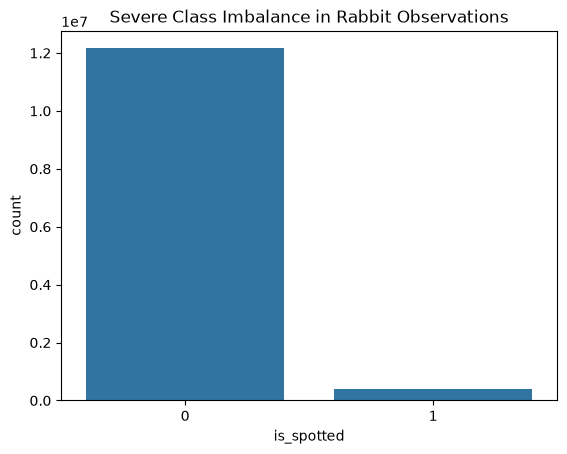

In [8]:
sns.countplot(data=df, x='is_spotted')
plt.title('Severe Class Imbalance in Rabbit Observations')
plt.show()

Generating clean plots for 12 variables...



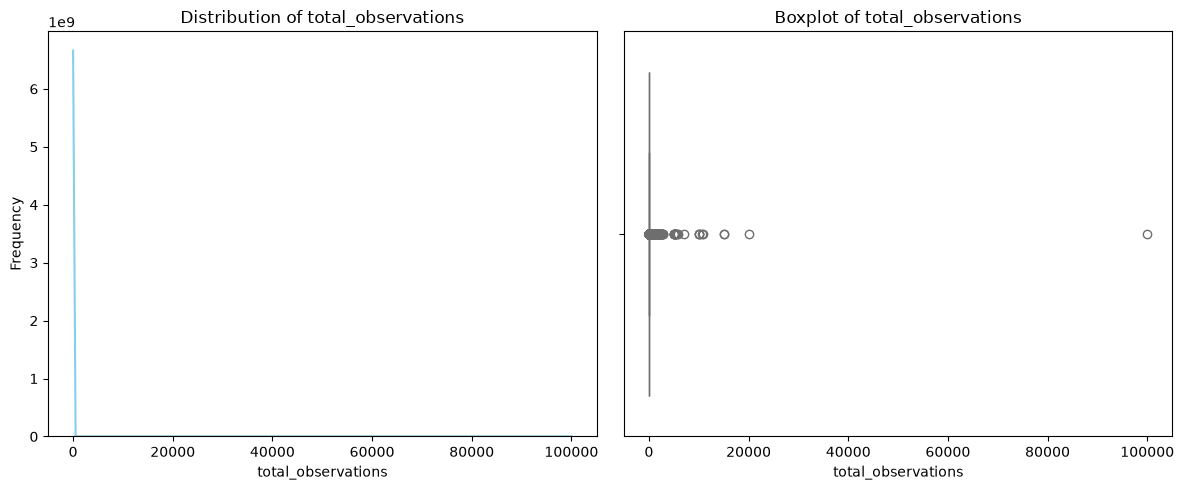


--- total_observations ---
Mean:     8.112
Median:   1.000
Std:      39.198
Min:      0.000
Max:      100040.000
Skewness: 1356.017
Missing:  0 rows
--------------------------------------------------


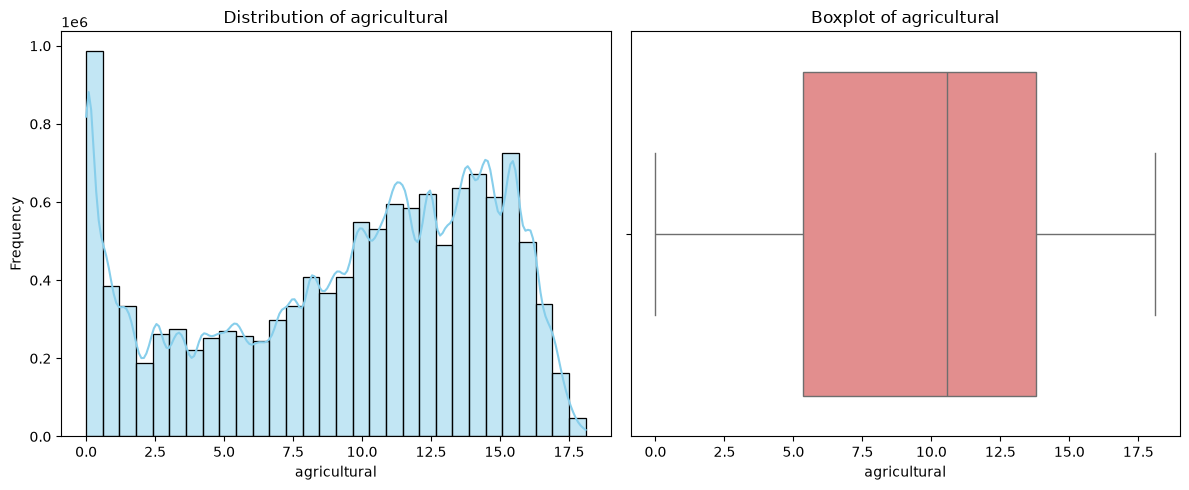


--- agricultural ---
Mean:     9.452
Median:   10.568
Std:      5.148
Min:      0.000
Max:      18.105
Skewness: -0.446
Missing:  0 rows
--------------------------------------------------


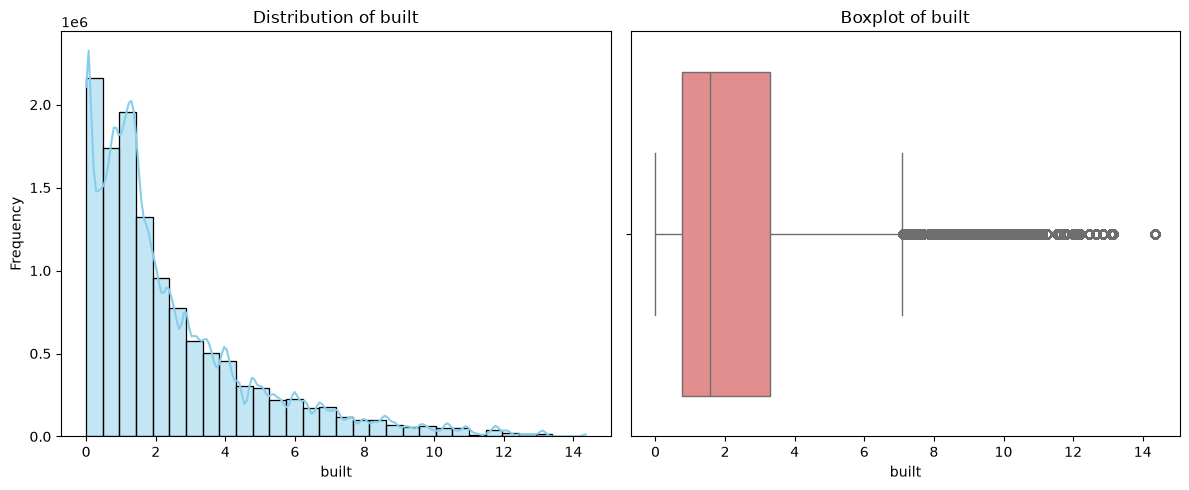


--- built ---
Mean:     2.405
Median:   1.560
Std:      2.420
Min:      0.000
Max:      14.354
Skewness: 1.710
Missing:  0 rows
--------------------------------------------------


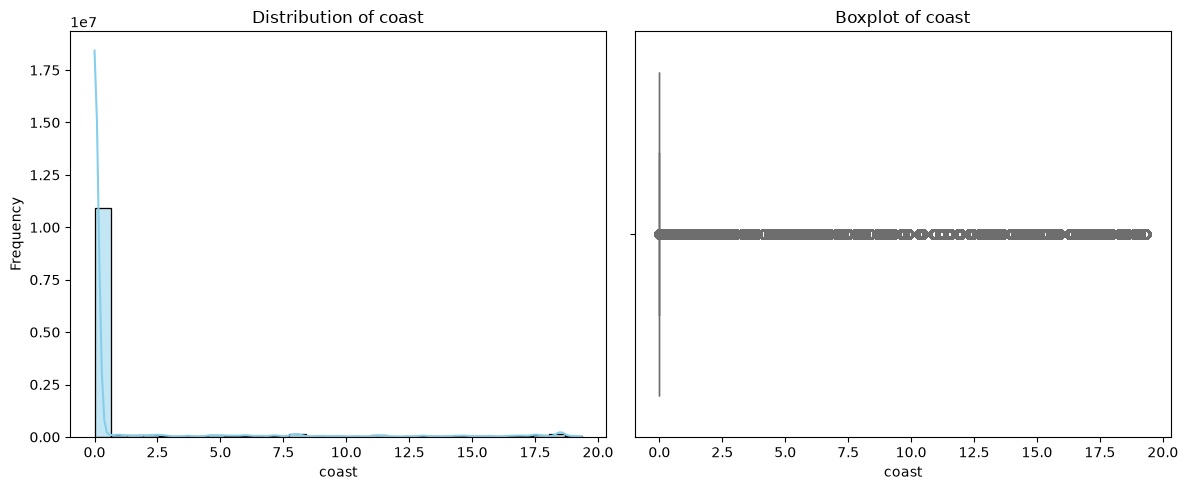


--- coast ---
Mean:     1.303
Median:   0.000
Std:      3.970
Min:      0.000
Max:      19.349
Skewness: 3.237
Missing:  0 rows
--------------------------------------------------


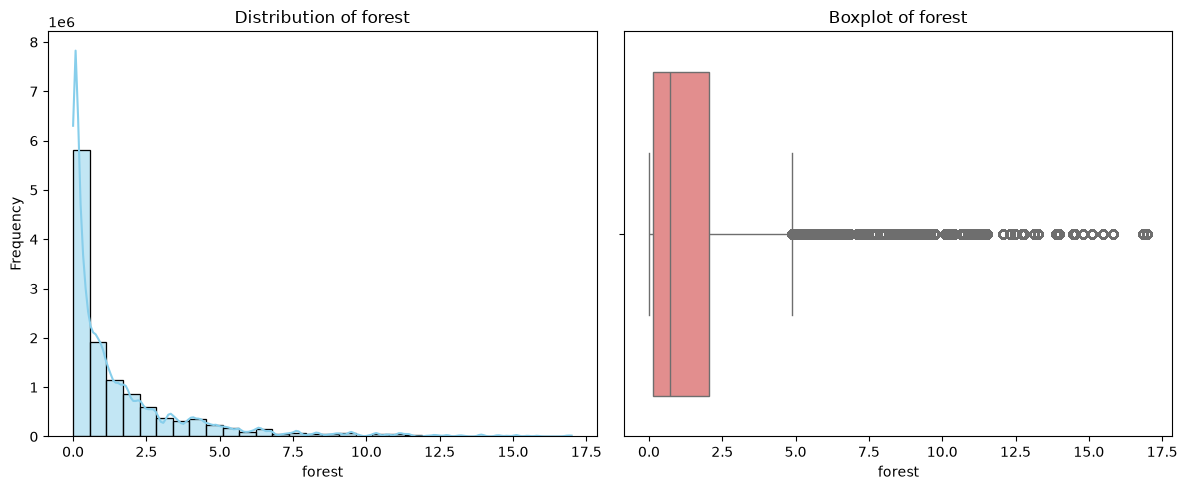


--- forest ---
Mean:     1.621
Median:   0.709
Std:      2.386
Min:      0.000
Max:      16.998
Skewness: 2.705
Missing:  0 rows
--------------------------------------------------


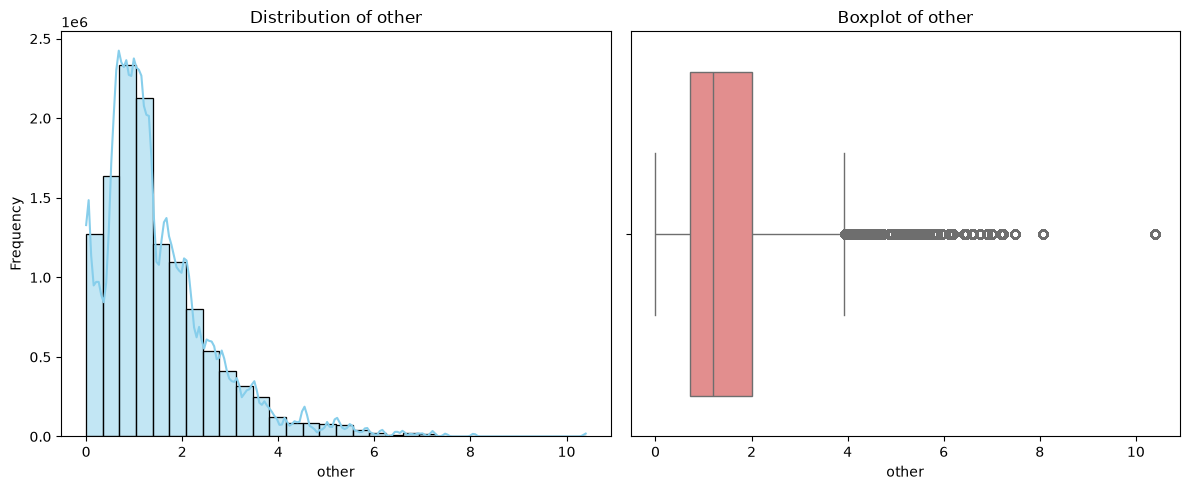


--- other ---
Mean:     1.501
Median:   1.200
Std:      1.168
Min:      0.000
Max:      10.398
Skewness: 1.754
Missing:  0 rows
--------------------------------------------------


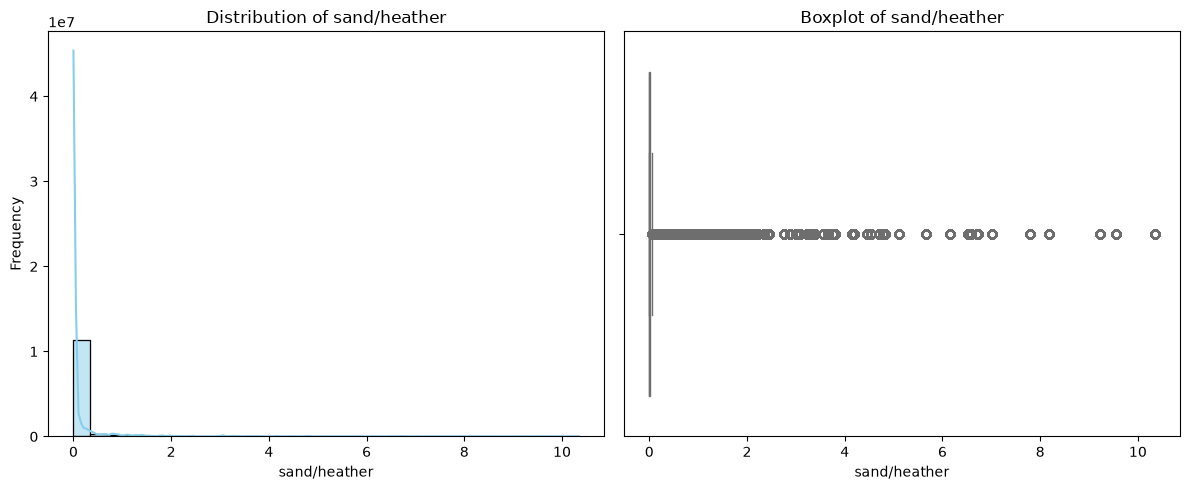


--- sand/heather ---
Mean:     0.188
Median:   0.000
Std:      0.771
Min:      0.000
Max:      10.344
Skewness: 7.121
Missing:  0 rows
--------------------------------------------------


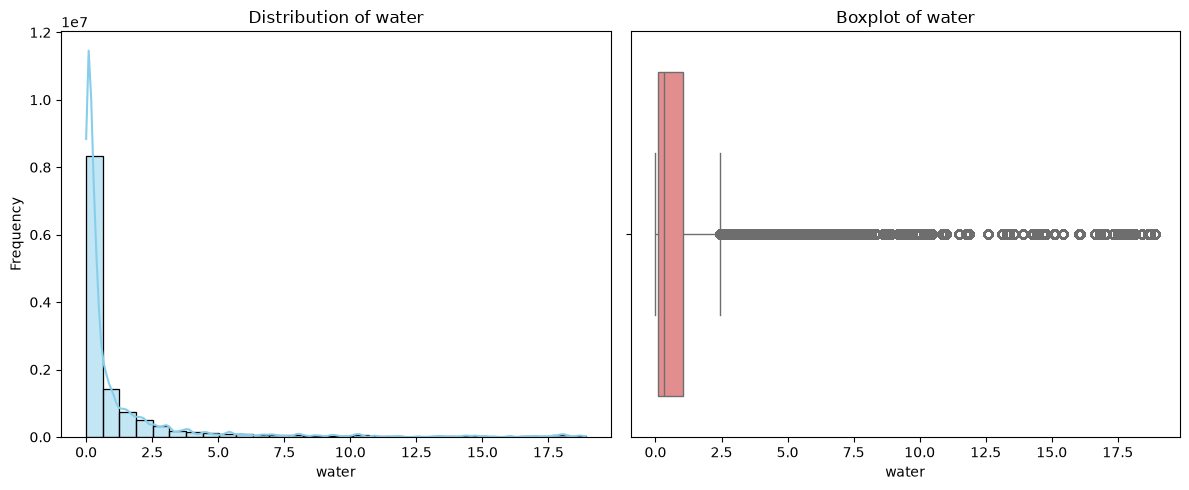


--- water ---
Mean:     1.246
Median:   0.310
Std:      2.688
Min:      0.000
Max:      18.909
Skewness: 4.065
Missing:  0 rows
--------------------------------------------------


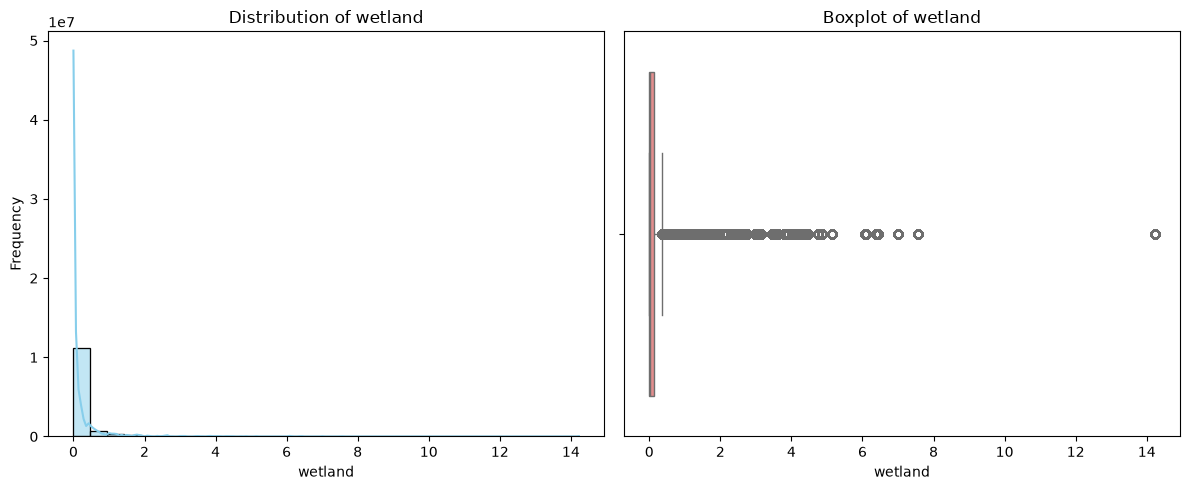


--- wetland ---
Mean:     0.225
Median:   0.018
Std:      0.706
Min:      0.000
Max:      14.224
Skewness: 8.013
Missing:  0 rows
--------------------------------------------------


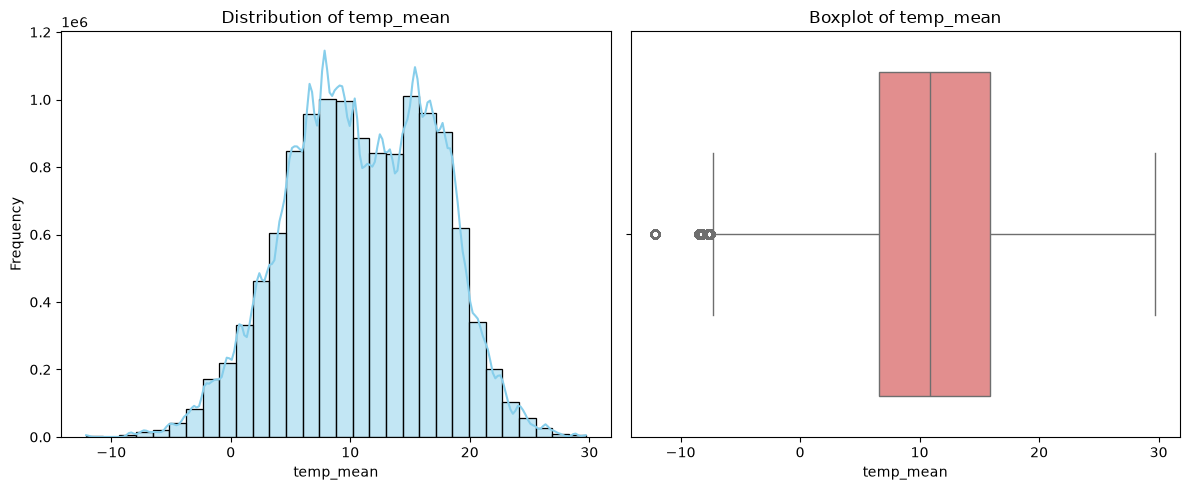


--- temp_mean ---
Mean:     10.996
Median:   10.900
Std:      6.155
Min:      -12.100
Max:      29.700
Skewness: -0.135
Missing:  0 rows
--------------------------------------------------


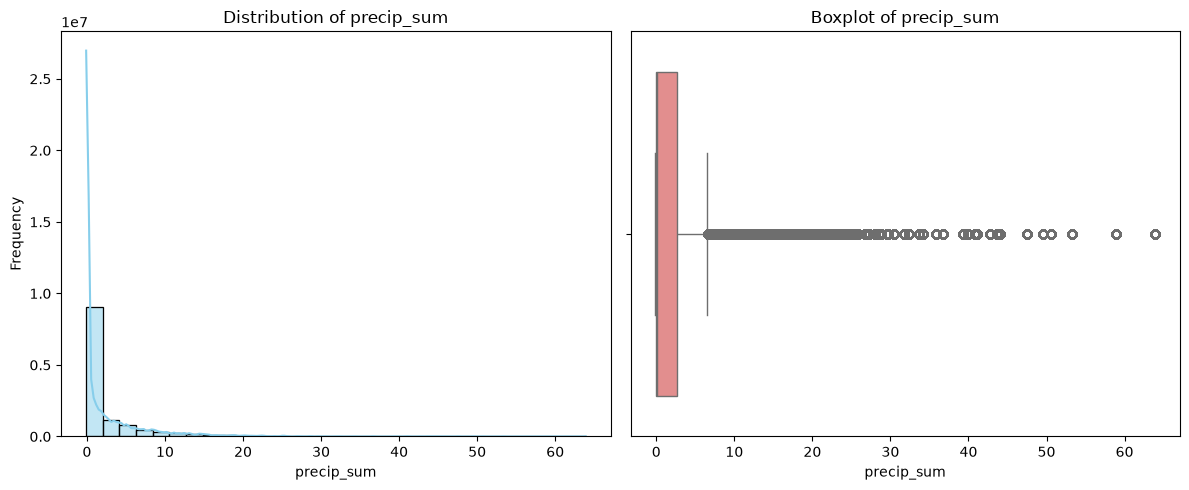


--- precip_sum ---
Mean:     2.369
Median:   0.100
Std:      4.901
Min:      -0.100
Max:      63.900
Skewness: 3.926
Missing:  0 rows
--------------------------------------------------


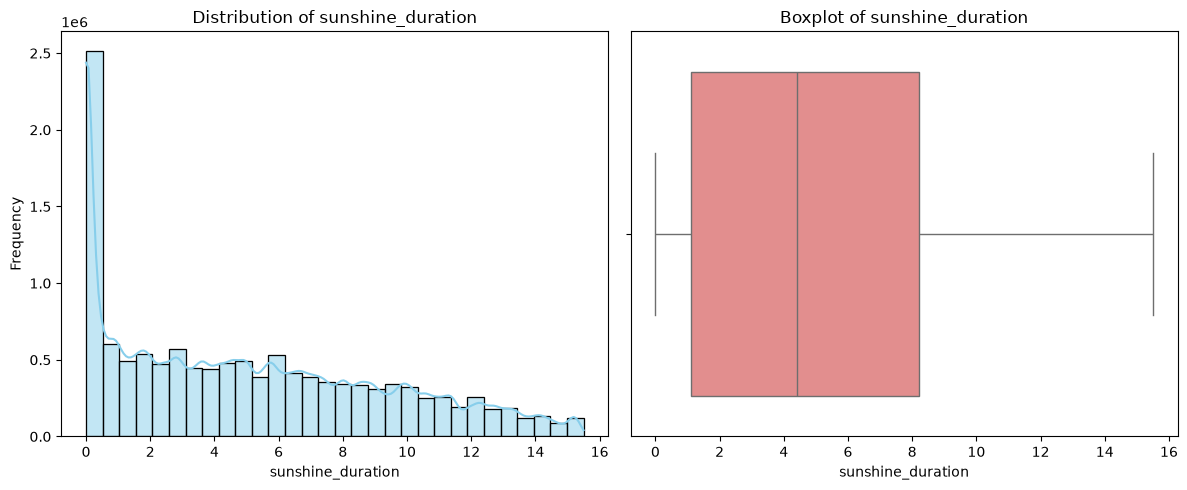


--- sunshine_duration ---
Mean:     5.040
Median:   4.400
Std:      4.252
Min:      0.000
Max:      15.500
Skewness: 0.543
Missing:  0 rows
--------------------------------------------------


In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ======================
# Select ONLY truly numeric columns
# ======================
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove columns that don't make sense for hist/boxplot
exclude_cols = ['decimalLatitude', 'decimalLongitude', 'day_of_year', 
                'day_sin', 'day_cos']

important_vars = [
    'total_observations', 
    'Oryctolagus cuniculus',   # this should now be numeric after cleaning
    'agricultural', 'built', 'coast', 'forest', 'other', 
    'sand/heather', 'water', 'wetland',
    'temp_mean', 'precip_sum', 'sunshine_duration'
]

# Filter to only existing important numeric columns
plot_vars = [col for col in important_vars if col in numeric_cols]

print(f"Generating clean plots for {len(plot_vars)} variables...\n")

for col in plot_vars:
    data = df[col].dropna()
    
    # Ensure it's numeric (safety check)
    data = pd.to_numeric(data, errors='coerce').dropna()
    
    if len(data) == 0:
        print(f"Skipping {col} - no numeric data")
        continue
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Histogram with KDE
    sns.histplot(data, kde=True, ax=axes[0], bins=30, color='skyblue')
    axes[0].set_title(f"Distribution of {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frequency")
    
    # Horizontal Boxplot
    sns.boxplot(x=data, ax=axes[1], orient="h", color='lightcoral')
    axes[1].set_title(f"Boxplot of {col}")
    axes[1].set_xlabel(col)
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print(f"\n--- {col} ---")
    print(f"Mean:     {data.mean():.3f}")
    print(f"Median:   {data.median():.3f}")
    print(f"Std:      {data.std():.3f}")
    print(f"Min:      {data.min():.3f}")
    print(f"Max:      {data.max():.3f}")
    print(f"Skewness: {data.skew():.3f}")
    print(f"Missing:  {df[col].isna().sum():,} rows")
    print("-" * 50)

*The histograms and boxplots for total_observations and speciesgroup_observations show that the most common value is zero. Due to the large number of zero values, the distributions are heavily right-skewed, causing even small positive values (greater than 1) to be identified as outliers in the boxplots. Therefore, the detected outliers do not necessarily represent errors or abnormal observations, but rather reflect the strong imbalance between zero and non-zero counts in the data.*

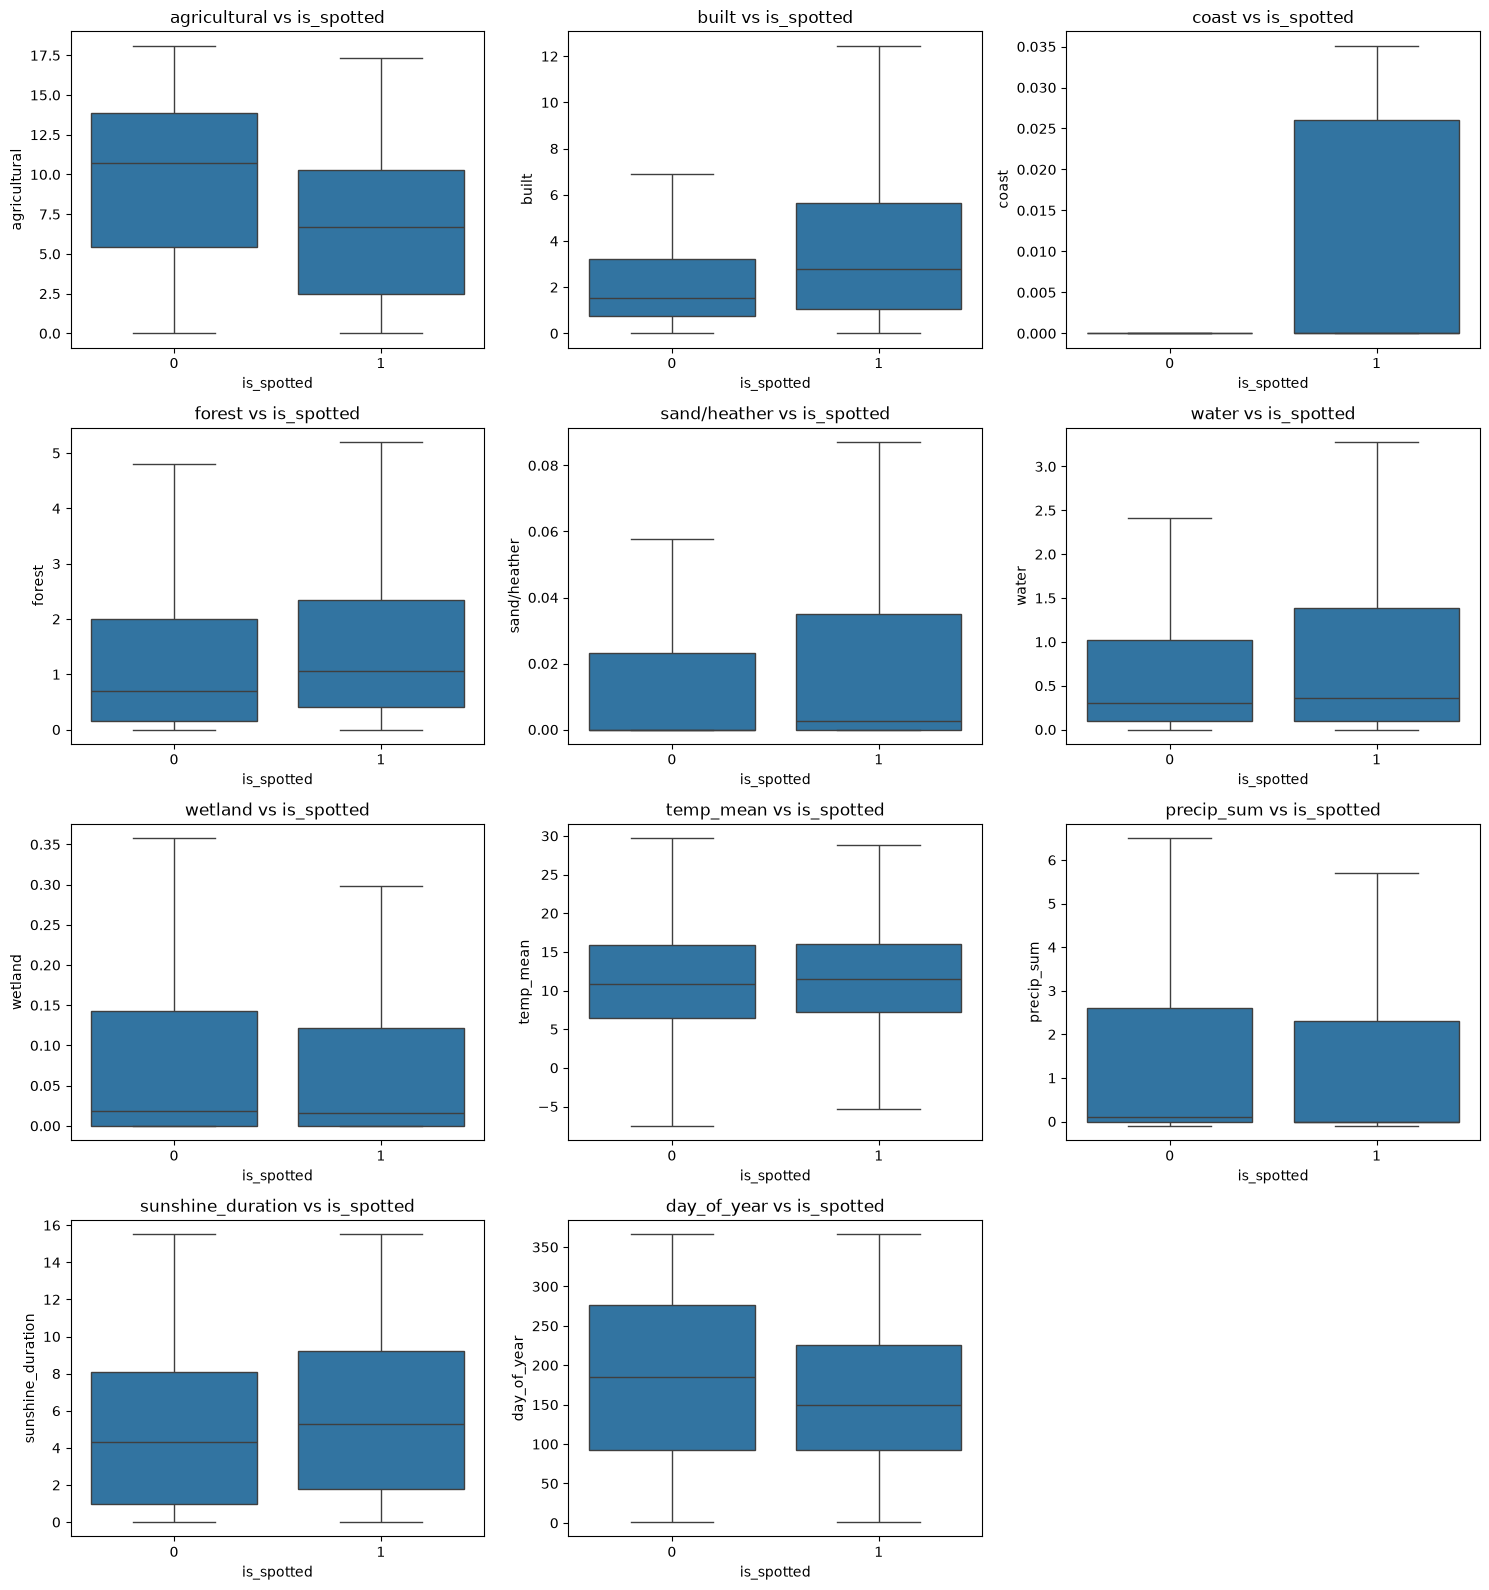

In [18]:
features = [
    'agricultural', 'built', 'coast', 'forest',
    'sand/heather', 'water', 'wetland',
    'temp_mean', 'precip_sum', 'sunshine_duration',
    'day_of_year'
]

target = 'is_spotted'

df_plot = df[[target] + features].copy()

df_plot = df_plot.replace("unknown", pd.NA)
df_plot = df_plot.apply(pd.to_numeric, errors='coerce')

df_plot = df_plot.dropna()

# Sample for speed
df_plot = df_plot.sample(50000, random_state=42)

n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 4))

for i, col in enumerate(features, 1):

    plt.subplot(n_rows, n_cols, i)

    sns.boxplot(
        x=target,
        y=col,
        data=df_plot,
        showfliers=False
    )

    plt.title(f"{col} vs is_spotted")

plt.tight_layout()
plt.show()

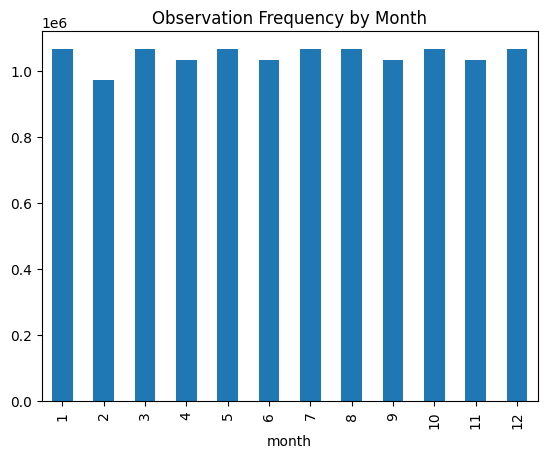

In [ ]:
df["eventDate"] = pd.to_datetime(df["eventDate"])

df["month"] = df["eventDate"].dt.month

df["month"].value_counts().sort_index().plot(kind="bar")

plt.title("Observation Frequency by Month")
plt.show()

**Findings**

I wanted to see if there was any seasonal pattern.
Because Bunnies have seasonal behaviors, for example bunny season is from march to september (its the breeding season for the bunnies).

Yet as you can see from the graph our data there is barely any monthly data change which is suprising.

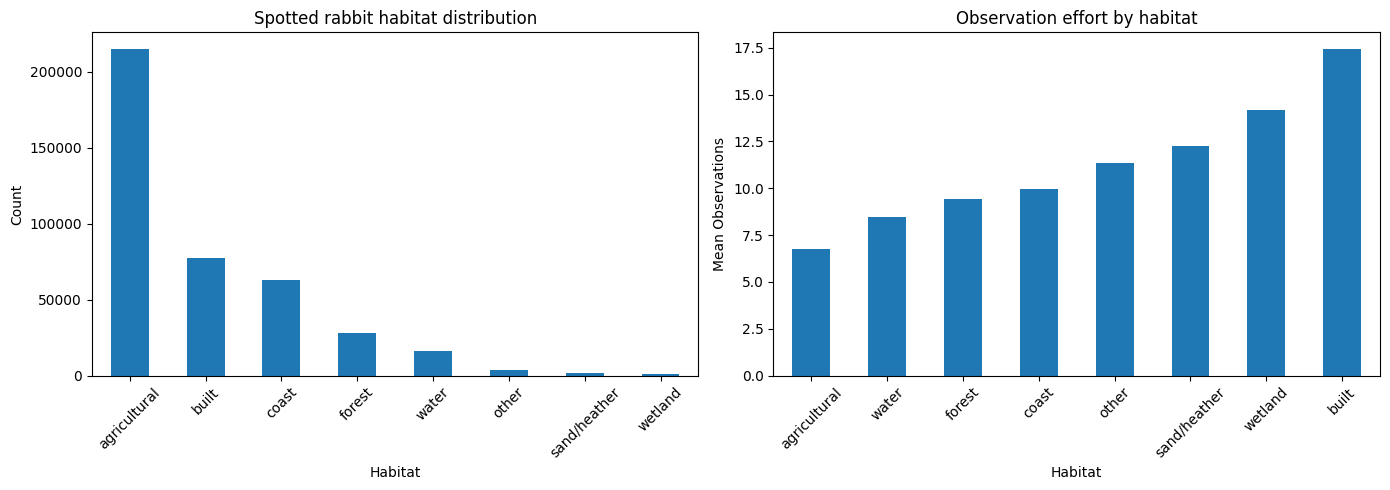

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# =========================================
# 1. Spotted rabbit habitat distribution
# =========================================
df[df["is_spotted"] == 1]["main_habitat"] \
    .value_counts() \
    .plot(kind="bar", ax=axes[0])

axes[0].set_title("Spotted rabbit habitat distribution")
axes[0].set_xlabel("Habitat")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

# =========================================
# 2. Observation effort by habitat
# =========================================
df.groupby("main_habitat")["total_observations"] \
    .mean() \
    .sort_values() \
    .plot(kind="bar", ax=axes[1])

axes[1].set_title("Observation effort by habitat")
axes[1].set_xlabel("Habitat")
axes[1].set_ylabel("Mean Observations")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# filter spotted rabbits
hab = df[df["is_spotted"] == 1]["main_habitat"]

# counts
counts = hab.value_counts(dropna=False)

# percentages
percentages = hab.value_counts(normalize=True, dropna=False) * 100

# combine into one dataframe
result = pd.DataFrame({
    "count": counts,
    "percentage": percentages.round(2)
})

print(result)

               count  percentage
main_habitat                    
agricultural  215183       53.18
built          77067       19.04
coast          63185       15.61
forest         27691        6.84
water          15927        3.94
other           3318        0.82
sand/heather    1406        0.35
wetland          883        0.22


**Findings**

Most rabbit observations are recorded in agricultural environments (68.75%), followed by built areas (12.41%). However, this distribution does not necessarily reflect true habitat preference, as observation effort varies across habitats.

The observation effort analysis shows that built areas and wetlands have a higher average number of observations. This indicates a potential sampling bias, likely due to these areas being more accessible or more frequently surveyed.

Interestingly, agricultural areas show the highest number of rabbit sightings despite not having the highest observation effort. This may suggest that rabbit presence is genuinely higher in these environments, rather than being solely driven by survey intensity.

Other habitats, such as sand/heather, wetlands, and forest, show relatively low observation effort and low numbers of sightings. Therefore, conclusions about rabbit habitat preference in these environments are less reliable.

**Rabbit spots related to habitat**

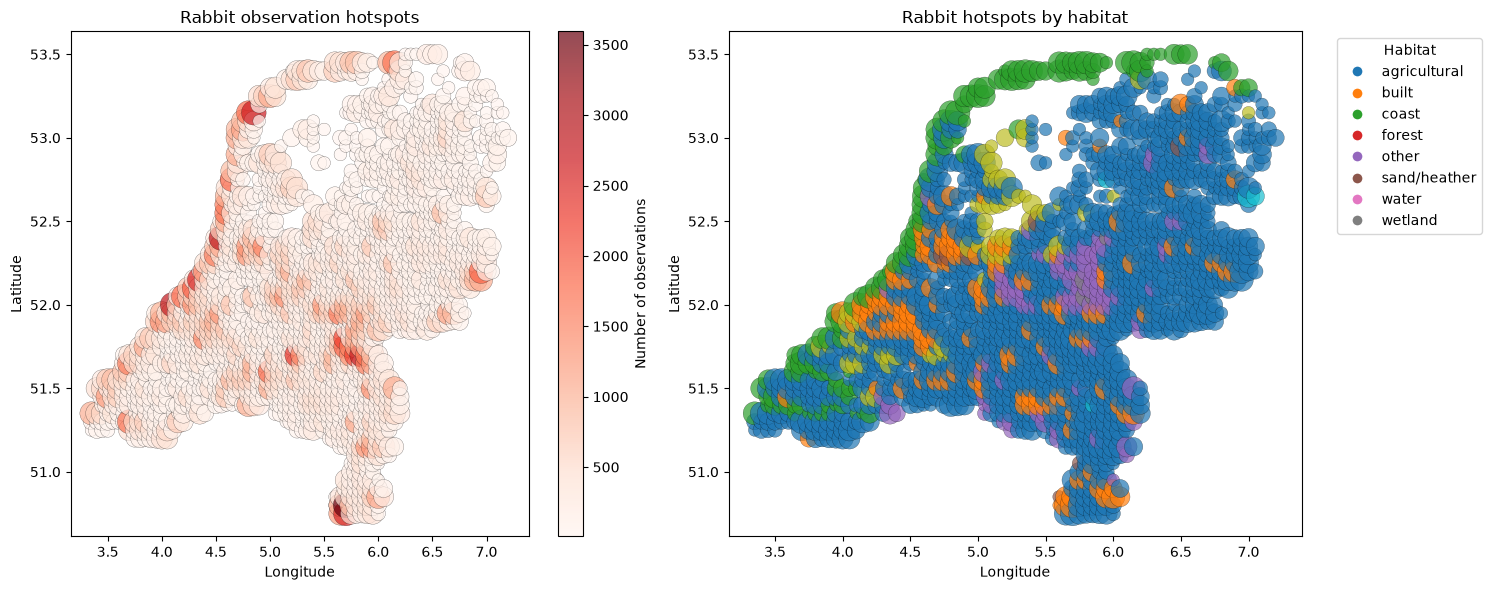

In [14]:
df_spotted = df[df["is_spotted"] == 1]

# =========================================
# 1. Location-only hotspot map
# =========================================
loc_counts_1 = df_spotted.groupby(
    ["decimalLongitude", "decimalLatitude"]
).size().reset_index(name="count")

loc_counts_1["log_count"] = np.log1p(loc_counts_1["count"])

# =========================================
# 2. Location + habitat map
# =========================================
loc_counts_2 = df_spotted.groupby(
    ["decimalLongitude", "decimalLatitude", "main_habitat"]
).size().reset_index(name="count")

loc_counts_2["log_count"] = np.log1p(loc_counts_2["count"])

habitats = loc_counts_2["main_habitat"].astype("category")
colors = habitats.cat.codes

# =========================================
# 3. Create side-by-side plots
# =========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# -------- LEFT: intensity only --------
sc1 = axes[0].scatter(
    loc_counts_1["decimalLongitude"],
    loc_counts_1["decimalLatitude"],
    s=loc_counts_1["log_count"] * 40,
    c=loc_counts_1["count"],
    cmap="Reds",
    alpha=0.7,
    edgecolors="black",
    linewidths=0.2
)

axes[0].set_title("Rabbit observation hotspots")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

cbar1 = plt.colorbar(sc1, ax=axes[0])
cbar1.set_label("Number of observations")

# -------- RIGHT: habitat + intensity --------
sc2 = axes[1].scatter(
    loc_counts_2["decimalLongitude"],
    loc_counts_2["decimalLatitude"],
    s=loc_counts_2["log_count"] * 40,
    c=colors,
    cmap="tab10",
    alpha=0.7,
    edgecolors="black",
    linewidths=0.2
)

axes[1].set_title("Rabbit hotspots by habitat")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

# habitat legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=cm.tab10(i),
               markersize=8,
               label=cat)
    for i, cat in enumerate(habitats.cat.categories)
]

axes[1].legend(handles=handles, title="Habitat",
               bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

**Findings**

Most of the rabbit observations are concentrated in specific geographic hotspots, showing a clear uneven spatial distribution of the data. This indicates that the dataset is not uniformly sampled across the study area.

The observation effort map shows that data collection is higher in agricultural and built environments, suggesting a potential sampling bias toward more accessible or frequently surveyed areas.

As a result, the observed habitat distribution of rabbits is likely influenced by where observations are made rather than only true habitat preference. Natural habitats such as forests, wetlands, and sand/heather are less represented, so conclusions about these areas are less reliable.

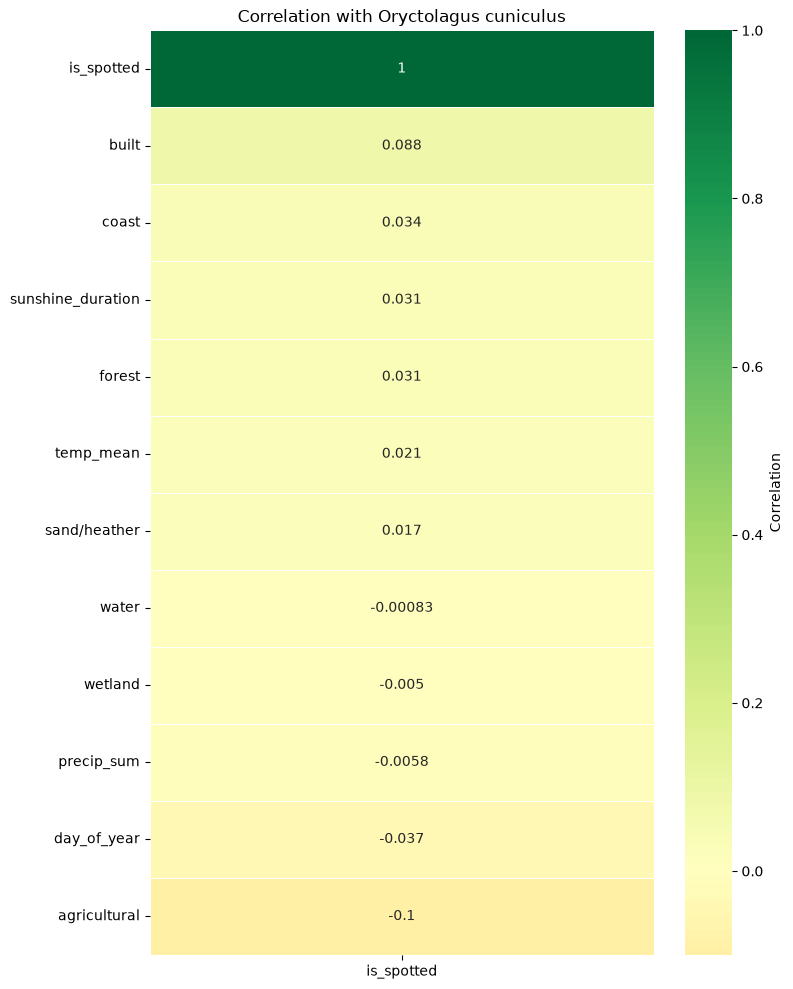

In [15]:
cols = [
    'is_spotted',
    'agricultural', 'built', 'coast', 'forest',
    'sand/heather', 'water', 'wetland',
    'temp_mean', 'precip_sum', 'sunshine_duration', 'day_of_year'
]

df_clean = df[cols].replace("unknown", pd.NA)

# drop rows with missing values
df_clean = df_clean.dropna()

corr = df_clean.corr()

# extract correlation with target
target_corr = corr[['is_spotted']].sort_values(
    by='is_spotted',
    ascending=False
)

plt.figure(figsize=(8, 10))

sns.heatmap(
    target_corr,
    annot=True,
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation'}
)

plt.title("Correlation with Oryctolagus cuniculus")
plt.tight_layout()
plt.show()

**Findings**

As you can see in the heatmap above there are no direct correlations with any variables

## Overall Findings of Data Understanding


# 2.2 Data preparation

**Check duplicates, missing values or typos**

In [10]:
df.isnull().sum()

decimalLatitude               0
decimalLongitude              0
eventDate                     0
total_observations            3
speciesgroup_observations     0
Oryctolagus cuniculus         0
agricultural                 30
built                        30
coast                        30
forest                       30
other                        30
sand/heather                 30
water                        30
wetland                      30
main_habitat                 30
temp_mean                     0
precip_sum                    0
sunshine_duration             0
spotted                       0
is_spotted                    0
day_of_year                   0
day_sin                       0
day_cos                       0
dtype: int64

In [11]:
df = df.dropna()
#check for missing values
df.isnull().sum()   

decimalLatitude              0
decimalLongitude             0
eventDate                    0
total_observations           0
speciesgroup_observations    0
Oryctolagus cuniculus        0
agricultural                 0
built                        0
coast                        0
forest                       0
other                        0
sand/heather                 0
water                        0
wetland                      0
main_habitat                 0
temp_mean                    0
precip_sum                   0
sunshine_duration            0
spotted                      0
is_spotted                   0
day_of_year                  0
day_sin                      0
day_cos                      0
dtype: int64

* *We removed all the zero values because when we took a closer look all the values were extreme and not similar at all to the rest of the data*

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
print(habitat["main_habitat"].unique())

<StringArray>
['agricultural',        'built',        'other',        'water',
       'forest',        'coast', 'sand/heather',      'wetland',
         'dirt']
Length: 9, dtype: str


# 3. Modeling
**Train test split**

In [ ]:
# ==========================
# TARGET
# ==========================
target = "is_spotted"

# ==========================
# FEATURES (EXPLICIT CLEAN SET)
# ==========================
features = [
    "agricultural",
    "built",
    "coast",
    "forest",
    "other",
    "sand/heather",
    "water",
    "wetland",
    "temp_mean",
    "precip_sum",
    "sunshine_duration",
    "day_sin",
    "day_cos"
]

# ==========================
# DATA
# ==========================
df_model = df[features + [target]].copy()

df_model = df_model.apply(pd.to_numeric, errors="coerce")
df_model = df_model.dropna()

X = df_model[features]
y = df_model[target]

# ==========================
# STRATIFIED K-FOLD
# ==========================
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    print(f"\nFOLD {fold + 1}")

    print("Train size:", len(X_train))
    print("Test size:", len(X_test))

    print("\nTrain class balance:")
    print(y_train.value_counts(normalize=True))

    print("\nTest class balance:")
    print(y_test.value_counts(normalize=True))

    print("-" * 40)


FOLD 1
Train size: 10047004
Test size: 2511752

Train class balance:
is_spotted
0    0.967779
1    0.032221
Name: proportion, dtype: float64

Test class balance:
is_spotted
0    0.967779
1    0.032221
Name: proportion, dtype: float64
----------------------------------------

FOLD 2
Train size: 10047005
Test size: 2511751

Train class balance:
is_spotted
0    0.967779
1    0.032221
Name: proportion, dtype: float64

Test class balance:
is_spotted
0    0.967779
1    0.032221
Name: proportion, dtype: float64
----------------------------------------

FOLD 3
Train size: 10047005
Test size: 2511751

Train class balance:
is_spotted
0    0.967779
1    0.032221
Name: proportion, dtype: float64

Test class balance:
is_spotted
0    0.967779
1    0.032221
Name: proportion, dtype: float64
----------------------------------------

FOLD 4
Train size: 10047005
Test size: 2511751

Train class balance:
is_spotted
0    0.967779
1    0.032221
Name: proportion, dtype: float64

Test class balance:
is_spotte

We train test splitted the data into 80% training and 20% testing sets, while maintaining the same proportion of rabbit observations (is_spotted) in both sets.

Model

In [ ]:
model1 = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42
)

model1.fit(X_train, y_train)

y_pred = model1.predict(X_test)

print("Accuracy:")
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy:
0.7345095114921821
              precision    recall  f1-score   support

           0       0.98      0.74      0.84   2430819
           1       0.08      0.64      0.13     80932

    accuracy                           0.73   2511751
   macro avg       0.53      0.69      0.49   2511751
weighted avg       0.95      0.73      0.82   2511751

Recall: 0.640933129046607

Confusion Matrix:
[[1793033  637786]
 [  29060   51872]]


In [ ]:
model2 = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(y[y==0]) / len(y[y==1]),
    random_state=42,
    eval_metric='logloss'
)

# Train
model2.fit(X_train, y_train)

# Predict
y_pred = model2.predict(X_test)

# Evaluate
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1883864  546955]
 [  15407   65525]]
              precision    recall  f1-score   support

           0       0.99      0.77      0.87   2430819
           1       0.11      0.81      0.19     80932

    accuracy                           0.78   2511751
   macro avg       0.55      0.79      0.53   2511751
weighted avg       0.96      0.78      0.85   2511751



In [ ]:
# 1. Calculate the class imbalance ratio dynamically
ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# 2. Instantiate the base model
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')

# 3. Define the hyperparameter space to search
# We target the most impactful parameters for XGBoost
param_dist = {
    'n_estimators': [100, 300, 500],          # Number of gradient boosted trees
    'max_depth': [4, 6, 8],                    # Maximum tree depth for base learners
    'learning_rate': [0.01, 0.05, 0.1],        # Boosting learning rate (eta)
    'subsample': [0.7, 0.8, 0.9],              # Subsample ratio of the training instances
    'colsample_bytree': [0.7, 0.8, 0.9],       # Subsample ratio of columns when constructing each tree
    'scale_pos_weight': [ratio]                # Kept static to handle your 10% minority class
}

# 4. Set up RandomizedSearchCV
# Note: We use scoring='f1' or 'roc_auc' because accuracy is misleading for 10% imbalanced data
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=10,                # Number of parameter settings sampled (Adjust based on your time constraints)
    scoring='f1',             # Focuses on balancing Precision & Recall for the 10% "True" target
    cv=3,                     # 3-fold cross-validation to prevent overfitting
    verbose=2,                # Shows progress during training
    random_state=42,
    n_jobs=-1                 # Uses all available CPU cores for speed
)

# 5. Run the hyperparameter search
print("Starting hyperparameter tuning...")
random_search.fit(X_train, y_train)

# 6. Extract the best model and parameters
best_model = random_search.best_estimator_
print("\n--- Tuning Complete ---")
print(f"Best Parameters Found: {random_search.best_params_}")
print(f"Best CV F1-Score: {random_search.best_score_:.4f}\n")

# 7. Predict and Evaluate using the tuned model
y_pred_tuned = best_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

Starting hyperparameter tuning...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

--- Tuning Complete ---
Best Parameters Found: {'subsample': 0.8, 'scale_pos_weight': 30.035325952651608, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Best CV F1-Score: 0.2022

Confusion Matrix:
[[1913523  517297]
 [  14005   66927]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.79      0.88   2430820
           1       0.11      0.83      0.20     80932

    accuracy                           0.79   2511752
   macro avg       0.55      0.81      0.54   2511752
weighted avg       0.96      0.79      0.86   2511752

